
Creating Traffic Sign Dataset...

Dataset Preview:

   Sign_ID  Red_Color_Intensity  Circular_Shape  Text_Present  Edge_Count  \
0        1                 0.90               0             1           8   
1        2                 0.20               1             0           4   
2        3                 0.85               0             1           7   
3        4                 0.30               1             0           5   
4        5                 0.88               0             1           8   

   Stop_Sign  
0          1  
1          0  
2          1  
3          0  
4          1  

Full Dataset:

   Sign_ID  Red_Color_Intensity  Circular_Shape  Text_Present  Edge_Count  \
0        1                 0.90               0             1           8   
1        2                 0.20               1             0           4   
2        3                 0.85               0             1           7   
3        4                 0.30               1             0         

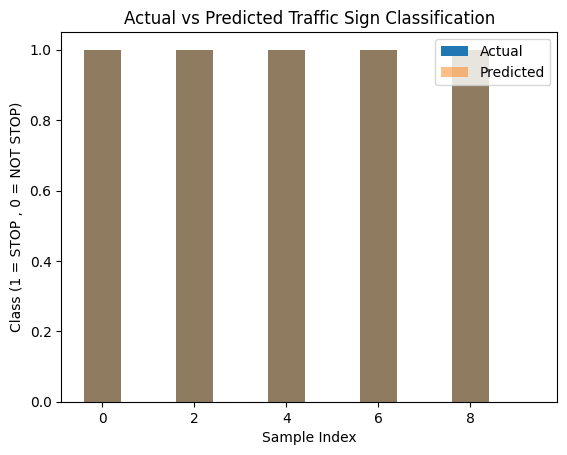


Predicting New Traffic Sign...

Traffic Sign is STOP Sign.


In [7]:
# Capstone Project 4
# Smart Traffic Sign Recognition System (Neural Network Project)
# Scenario:
# A city is building a Smart Traffic Monitoring System to improve road safety.

# Every intersection in the city will have cameras that detect traffic signs automatically.

# The system must recognize different road signs such as:
# - Stop Sign
# - Speed Limit Sign
# - Pedestrian Crossing Sign

# The system will be used in autonomous vehicles and traffic monitoring cameras.

# Engineers discovered two challenges:

# 1. The system must understand basic classification logic.
# 2. The system must classify traffic sign images captured by cameras.

# To solve this problem the system is built in two stages.


# Stage 1
# Learning Basic Neural Networks (Perceptron)

# Before building a full deep learning model, engineers first implement
# a simple perceptron neural network to understand how neural networks
# make decisions.

# The perceptron will classify whether a traffic sign means:
# STOP (1)
# NOT STOP (0)

# using extracted features.



# Technology Stack Used


# Python
# Python is used because it provides strong libraries for
# machine learning and neural networks.

# NumPy
# NumPy is used for numerical computations and matrix operations
# required in neural networks.

# Pandas
# Pandas is used to create and manage dataset tables.

# Matplotlib
# Matplotlib is used for visualizing results and data patterns.

# Perceptron
# A Perceptron is the simplest type of neural network.
# It learns by adjusting weights using training data
# and predicts class labels.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# Creating Traffic Sign Dataset


print("\nCreating Traffic Sign Dataset...\n")

data = pd.read_csv("DatasetCapstoneProject4.csv")

print("Dataset Preview:\n")
print(data.head())

df = pd.DataFrame(data)

print("\nFull Dataset:\n")
print(df)

print("\nDataset Shape:", df.shape)



# Define Features and Target


print("\nSeparating Features and Target...\n")

# Remove Sign_ID and Target column
X = df.drop(["Sign_ID","Stop_Sign"], axis=1).values
y = df["Stop_Sign"].values

print("Features:\n", X)
print("\nTarget:\n", y)



# Initialize Perceptron Parameters


print("\nInitializing Perceptron Weights...\n")

weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 10



# Activation Function


def step_function(z):
    if z >= 0:
        return 1
    else:
        return 0



# Training the Perceptron


print("\nTraining Perceptron Model...\n")

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}")

    for i in range(len(X)):

        linear_output = np.dot(X[i], weights) + bias
        y_pred = step_function(linear_output)

        error = y[i] - y_pred

        weights = weights + learning_rate * error * X[i]
        bias = bias + learning_rate * error

        print("Sample:", i,
              "Predicted:", y_pred,
              "Actual:", y[i],
              "Error:", error)

print("\nTraining Completed.")


print("\nFinal Weights:", weights)
print("Final Bias:", bias)



# Predictions


print("\nMaking Predictions...\n")

predictions = []

for i in range(len(X)):
    linear_output = np.dot(X[i], weights) + bias
    y_pred = step_function(linear_output)
    predictions.append(y_pred)

print("Predictions:", predictions)



# Accuracy Calculation


accuracy = np.mean(predictions == y)

print("\nModel Accuracy:", accuracy)



# Visualization Graph


print("\nVisualizing Prediction Results...\n")

plt.figure()

plt.bar(range(len(y)), y, label="Actual")
plt.bar(range(len(predictions)), predictions, alpha=0.5, label="Predicted")

plt.title("Actual vs Predicted Traffic Sign Classification")
plt.xlabel("Sample Index")
plt.ylabel("Class (1 = STOP , 0 = NOT STOP)")
plt.legend()

plt.show()



# Predict New Traffic Sign


print("\nPredicting New Traffic Sign...\n")

# [Red_Color_Intensity, Circular_Shape, Text_Present, Edge_Count]
new_sign = np.array([0.9,0,1,8])

linear_output = np.dot(new_sign, weights) + bias
prediction = step_function(linear_output)

if prediction == 1:
    print("Traffic Sign is STOP Sign.")
else:
    print("Traffic Sign is NOT STOP Sign.")